# Imports

In [86]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters

In [101]:
wd = os.getcwd()
data_path = wd + "\\asian\\ASIAN.DAT"

save_path = wd + "\\prep_data\\data_"

# Load data

In [88]:
# Fixed columm width specification
colspecs = [
    (0, 4),   # ChildID
    (4, 7),   # Age
    (7, 12),  # Weight
    (12, 16), # BirthWeight
    (16, 17)  # Gender
]

column_names = ["ChildID", "Age", "Weight", "BirthWeight", "Gender"]

# data load
df = pd.read_fwf(data_path, colspecs=colspecs, names=column_names)

df.head()

,ChildID,Age,Weight,BirthWeight,Gender
0,2,377.0,10262.0,3360.0,2.0
1,2,825.0,14500.0,3360.0,2.0
2,3,54.0,4053.0,3310.0,2.0
3,3,242.0,8136.0,3310.0,2.0
4,3,377.0,9752.0,3310.0,2.0


# Exploratory analysis

In [89]:
df_count = df.groupby(["ChildID"]).count().reset_index()

df_count["NObs"] = df_count["Age"]
df_count = df_count[["ChildID", "NObs"]]
[print(i, ":", len(df_count[df_count["NObs"] == i]))for i in np.unique(df_count["NObs"])]

0 : 1
1 : 91
2 : 141
3 : 169
4 : 143
5 : 24


[None, None, None, None, None, None]

In [90]:
df = pd.merge(df,
              df_count,
              on = "ChildID", how = "left")

## Excluding NA observations

In [91]:
# Observe the one strange observation with NObs = 0
display(df.query("NObs == 0"))
df.query("NObs == 0")["ChildID"].iloc[0]

,ChildID,Age,Weight,BirthWeight,Gender,NObs
1572,,NaN,NaN,NaN,NaN,0


'\x1a'

In [92]:
print(len(df))
df = df[df["ChildID"] != '\x1a']
print(len(df))

1573
1572


In [93]:
df.isnull().sum()

# No more NA values are present

ChildID        0
Age            0
Weight         0
BirthWeight    0
Gender         0
NObs           0
dtype: int64

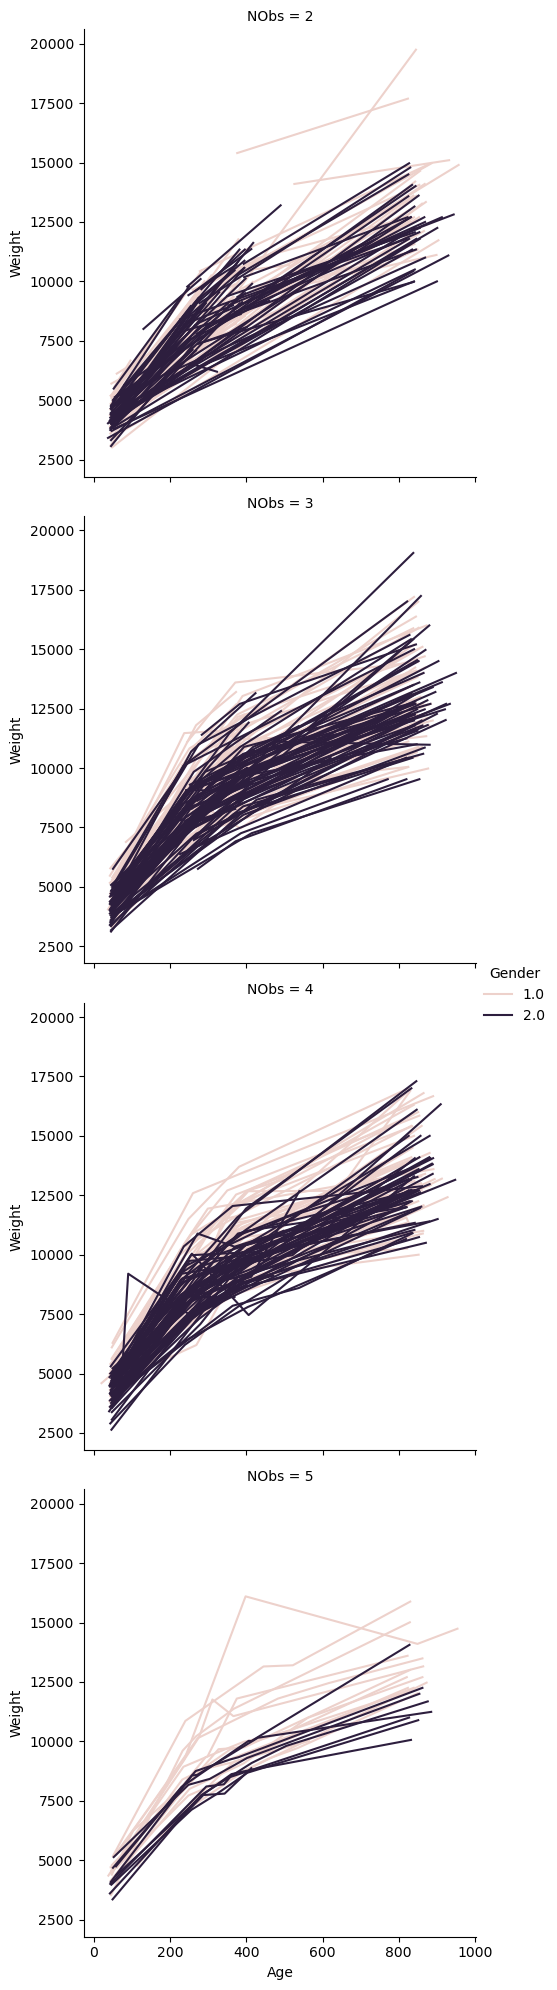

In [94]:
sns.relplot(
    x = "Age",
    y = "Weight",
    data = df.query("NObs >=2"),
    kind = "line",
    estimator = None,
    units = "ChildID",
    hue = "Gender",
    row = "NObs"
)

## Ideas so far:

- It seems that using logarithm of the age may be a good idea
- We might rescale other covariates to avoid big numbers for numerical stability
- We might include the birth weight as target variable values at the age 0. Then if we take logarithm, we first add +1 to all age values.

# Preparation

### Birthweight into target variable at start

In [95]:
df_age0 = df.copy()[['ChildID', 'BirthWeight', 'Gender', "NObs"]]
df_age0['Age'] = 0
df_age0['Weight'] = df_age0['BirthWeight']

In [96]:
df_w0 = pd.concat([df_age0[["ChildID", "Age", "Weight", "Gender", "NObs"]],
                   df[["ChildID", "Age", "Weight", "Gender", "NObs"]]])
df_w0["NObs"]+=1

### Logarithm of age variable

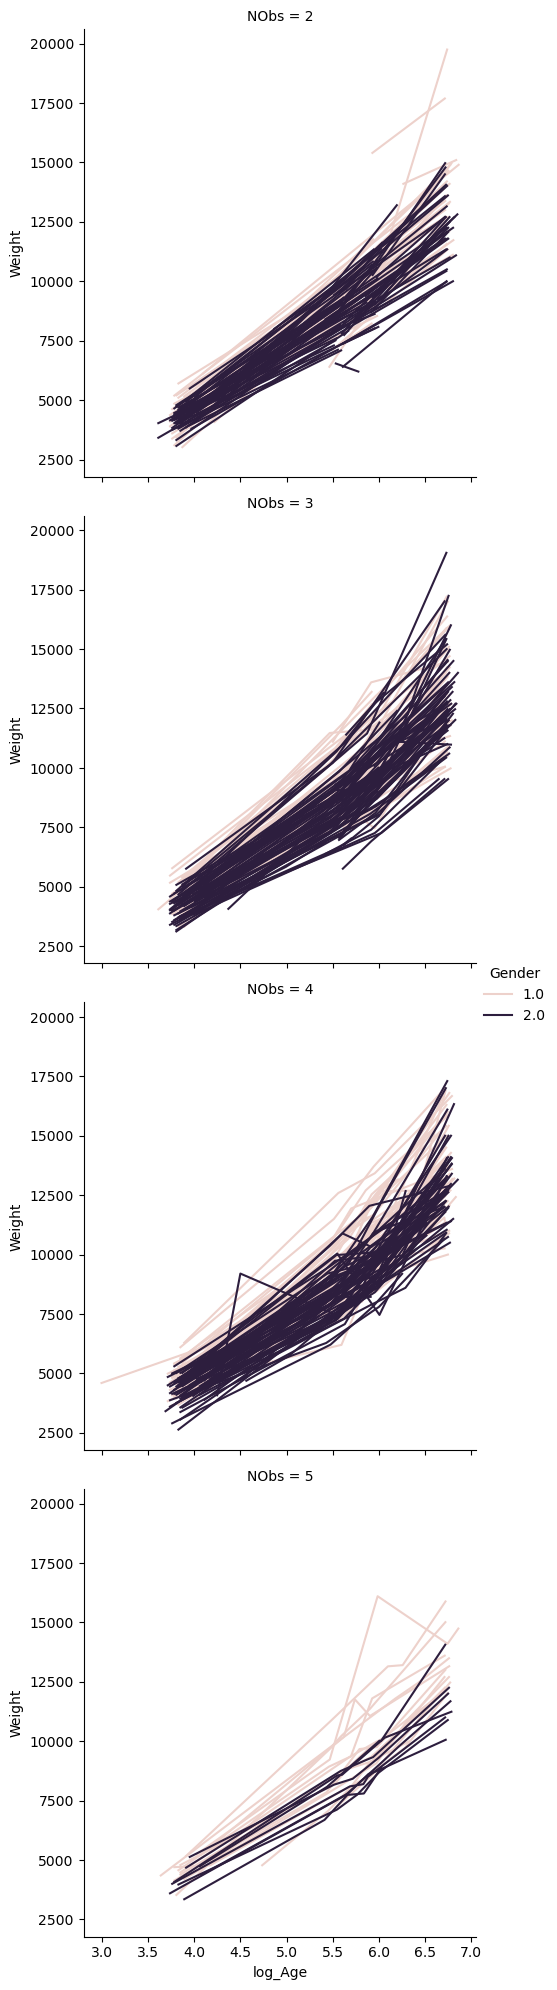

In [97]:
df["log_Age"] = np.log(df["Age"])

sns.relplot(
    x = "log_Age",
    y = "Weight",
    data = df.query("NObs >=2"),
    kind = "line",
    estimator = None,
    units = "ChildID",
    hue = "Gender",
    row = "NObs"
)

In [98]:
df_w0["log_Age"] = np.log(df_w0["Age"] + 1)

### Rescaling?

In [ ]:
###

## Divide into separate datasets wrt number of observations

In [99]:
df_list = []
df_w0_list = []
for i in range(1, 6):
    id_list = list(np.unique(df[df["NObs"] == i]["ChildID"]))

    df_list.append(df.loc[df["ChildID"].isin(id_list)])
    df_w0_list.append(df_w0.loc[df_w0["ChildID"].isin(id_list)])

[     ChildID    Age   Weight  BirthWeight  Gender  NObs   log_Age
 10        23  243.0   8000.0       3330.0     2.0     1  5.493061
 11        42   67.0   5300.0       3370.0     1.0     1  4.204693
 28       103   44.0   4900.0       3300.0     1.0     1  3.784190
 29       104  860.0  12700.0       3200.0     2.0     1  6.756932
 49       146   48.0   4200.0       3345.0     2.0     1  3.871201
 ...      ...    ...      ...          ...     ...   ...       ...
 1417    4628  458.0  10000.0       3185.0     2.0     1  6.126869
 1446    4703  864.0  13600.0       2860.0     1.0     1  6.761573
 1447    4717   42.0   4740.0       3610.0     2.0     1  3.737670
 1477    4803  840.0  12250.0       2710.0     2.0     1  6.733402
 1571    5020  830.0  13600.0       3300.0     2.0     1  6.721426
 
 [91 rows x 7 columns],
      ChildID    Age   Weight  BirthWeight  Gender  NObs   log_Age
 0          2  377.0  10262.0       3360.0     2.0     2  5.932245
 1          2  825.0  14500.0       

In [100]:
df1, df2, df3, df4, df5 = df_list
df_w01, df_w0_2, df_w03, df_w04, df_w05 = df_w0_list

# Save data

In [103]:
for i in range(0, len(df_list)):
    df_list[i].to_csv(f"{save_path}_{i+1}_obs_wide.csv")
    df_w0_list[i].to_csv(f"{save_path}_{i+1}_obs_long.csv")